<a id="1"></a>
# <div style="text-align:center; border-radius:15px 50px; padding:15px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color:#000000; overflow:hidden"><b> Visualize the three components of attention </b></div>

##  Why Do We Need Attention?

### The Problem with Traditional RNNs/LSTMs:

Imagine translating: "The cat sat on the mat because it was comfortable"
                  to: "Le chat s'est assis sur le tapis car c'était confortable"

Traditional RNNs compress the ENTIRE input sentence into a single fixed-size vector.
This creates an information bottleneck!

**The Attention Solution:**
Instead of one vector, let the decoder look at ALL encoder states and 
decide which parts to focus on at each step.

##  How Attention Works: Three Simple Steps

Think of attention like a **search engine**:

1. **Query**: What am I looking for? (current decoder state)
2. **Keys**: What information is available? (all encoder states)
3. **Values**: What is the actual content? (also encoder states)

**The Process:**
1. Compare Query with all Keys → Get similarity scores
2. Convert scores to probabilities (softmax) → Get attention weights
3. Weighted sum of Values → Get context vector


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from matplotlib.colors import LinearSegmentedColormap
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

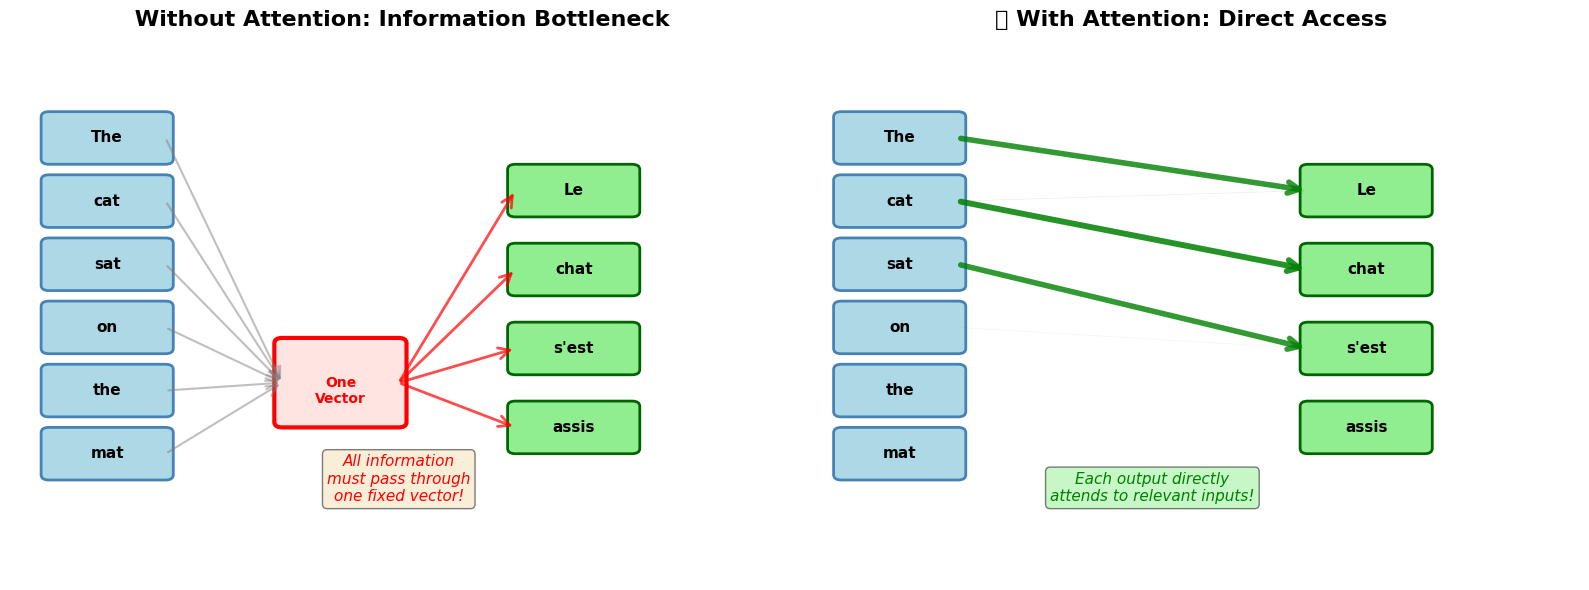

 Attention motivation visualized


In [5]:
def visualize_bottleneck():
   
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
   
    ax = axes[0]
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')
    ax.set_title(' Without Attention: Information Bottleneck', 
                 fontsize=16, fontweight='bold', pad=20)
    
    # Input words
    input_words = ['The', 'cat', 'sat', 'on', 'the', 'mat']
    for i, word in enumerate(input_words):
        box = FancyBboxPatch((0.5, 8 - i*1.2), 1.5, 0.8, 
                             boxstyle="round,pad=0.1", 
                             edgecolor='steelblue', facecolor='lightblue', 
                             linewidth=2)
        ax.add_patch(box)
        ax.text(1.25, 8.4 - i*1.2, word, ha='center', va='center', 
                fontsize=11, fontweight='bold')
    
    # Bottleneck (single context vector)
    bottleneck = FancyBboxPatch((3.5, 3), 1.5, 1.5, 
                                boxstyle="round,pad=0.1",
                                edgecolor='red', facecolor='mistyrose', 
                                linewidth=3)
    ax.add_patch(bottleneck)
    ax.text(4.25, 3.75, '\nOne\nVector', ha='center', va='center', 
            fontsize=10, fontweight='bold', color='red')
    
    # Arrows from inputs to bottleneck
    for i in range(len(input_words)):
        arrow = FancyArrowPatch((2, 8.4 - i*1.2), (3.5, 3.75),
                               arrowstyle='->', mutation_scale=20, 
                               linewidth=1.5, color='gray', alpha=0.5)
        ax.add_patch(arrow)
    
    # Output words
    output_words = ['Le', 'chat', 's\'est', 'assis']
    for i, word in enumerate(output_words):
        box = FancyBboxPatch((6.5, 7 - i*1.5), 1.5, 0.8, 
                             boxstyle="round,pad=0.1",
                             edgecolor='darkgreen', facecolor='lightgreen', 
                             linewidth=2)
        ax.add_patch(box)
        ax.text(7.25, 7.4 - i*1.5, word, ha='center', va='center', 
                fontsize=11, fontweight='bold')
        
        # Arrow from bottleneck to output
        arrow = FancyArrowPatch((5, 3.75), (6.5, 7.4 - i*1.5),
                               arrowstyle='->', mutation_scale=20, 
                               linewidth=2, color='red', alpha=0.7)
        ax.add_patch(arrow)
    
    ax.text(5, 1.5, 'All information\nmust pass through\none fixed vector!', 
            ha='center', fontsize=11, style='italic', color='red',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # With Attention - Direct Access
    ax = axes[1]
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis('off')
    ax.set_title(' With Attention: Direct Access', 
                 fontsize=16, fontweight='bold', pad=20)
    
    # Input words
    for i, word in enumerate(input_words):
        box = FancyBboxPatch((0.5, 8 - i*1.2), 1.5, 0.8, 
                             boxstyle="round,pad=0.1",
                             edgecolor='steelblue', facecolor='lightblue', 
                             linewidth=2)
        ax.add_patch(box)
        ax.text(1.25, 8.4 - i*1.2, word, ha='center', va='center', 
                fontsize=11, fontweight='bold')
    
    # Output words with attention connections
    for i, word in enumerate(output_words):
        box = FancyBboxPatch((6.5, 7 - i*1.5), 1.5, 0.8, 
                             boxstyle="round,pad=0.1",
                             edgecolor='darkgreen', facecolor='lightgreen', 
                             linewidth=2)
        ax.add_patch(box)
        ax.text(7.25, 7.4 - i*1.5, word, ha='center', va='center', 
                fontsize=11, fontweight='bold')
        
        # Attention connections (selective, varying thickness)
        # "Le" attends to "The"
        if i == 0:
            for j, weight in enumerate([0.8, 0.1, 0.05, 0.03, 0.01, 0.01]):
                if weight > 0.05:
                    arrow = FancyArrowPatch((2, 8.4 - j*1.2), (6.5, 7.4 - i*1.5),
                                           arrowstyle='->', mutation_scale=20, 
                                           linewidth=weight*5, color='green', 
                                           alpha=weight)
                    ax.add_patch(arrow)
      
        elif i == 1:
            for j, weight in enumerate([0.05, 0.85, 0.05, 0.03, 0.01, 0.01]):
                if weight > 0.05:
                    arrow = FancyArrowPatch((2, 8.4 - j*1.2), (6.5, 7.4 - i*1.5),
                                           arrowstyle='->', mutation_scale=20, 
                                           linewidth=weight*5, color='green', 
                                           alpha=weight)
                    ax.add_patch(arrow)
      
        elif i == 2:
            for j, weight in enumerate([0.02, 0.05, 0.8, 0.08, 0.03, 0.02]):
                if weight > 0.05:
                    arrow = FancyArrowPatch((2, 8.4 - j*1.2), (6.5, 7.4 - i*1.5),
                                           arrowstyle='->', mutation_scale=20, 
                                           linewidth=weight*5, color='green', 
                                           alpha=weight)
                    ax.add_patch(arrow)
    
    ax.text(4.5, 1.5, 'Each output directly\nattends to relevant inputs!', 
            ha='center', fontsize=11, style='italic', color='green',
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
    
    plt.tight_layout()
    plt.savefig('attention_motivation.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    
    print(" Attention motivation visualized")

visualize_bottleneck()

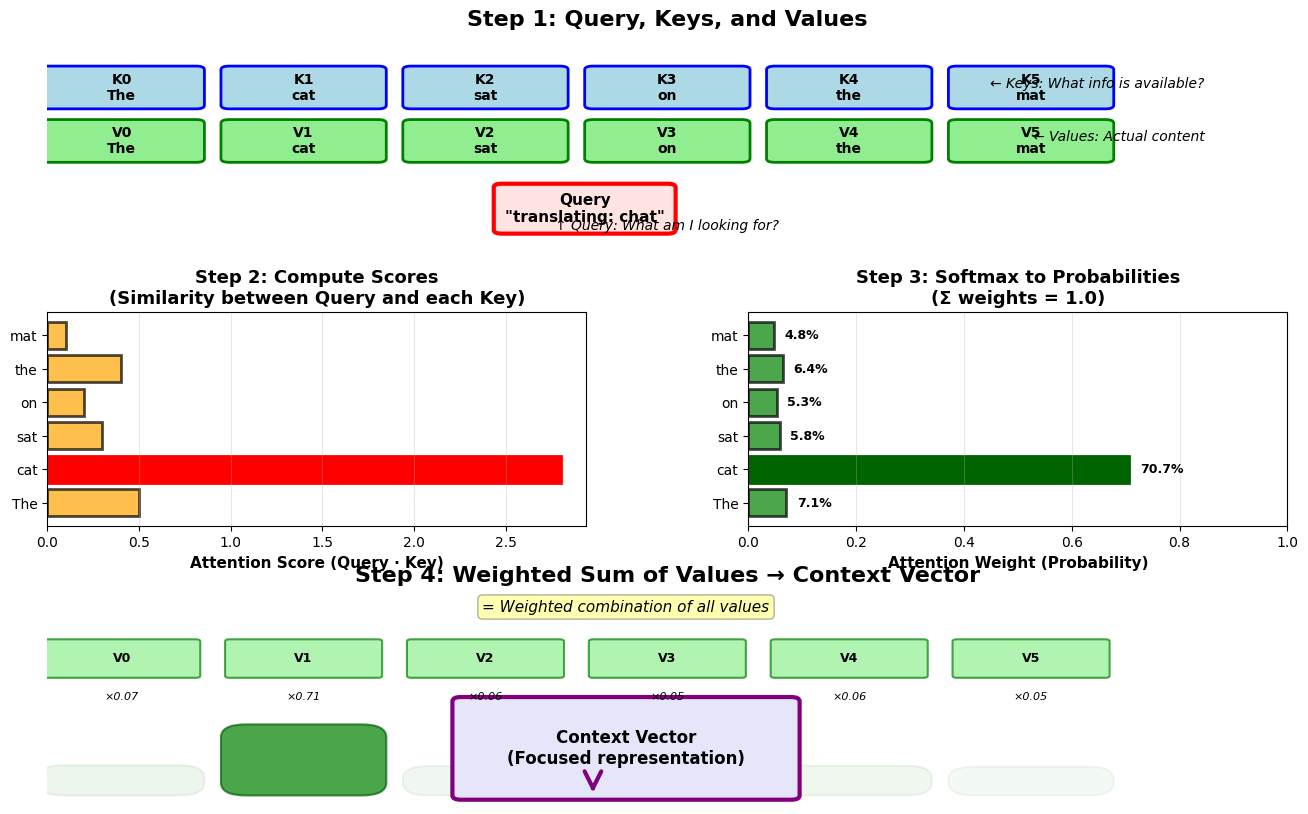

In [6]:
def visualize_attention_mechanism():
    
    
    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)
    
   
    sequence_length = 6
    hidden_dim = 4
    
    # Step 1: Query, Keys, Values
    ax1 = fig.add_subplot(gs[0, :])
    ax1.set_xlim(0, 15)
    ax1.set_ylim(0, 6)
    ax1.axis('off')
    ax1.set_title('Step 1: Query, Keys, and Values', 
                  fontsize=16, fontweight='bold')
    
    # Input sequence
    words = ['The', 'cat', 'sat', 'on', 'the', 'mat']
    for i, word in enumerate(words):
        # Key boxes
        box = FancyBboxPatch((i*2.2, 4), 1.8, 1, 
                             boxstyle="round,pad=0.1",
                             edgecolor='blue', facecolor='lightblue', 
                             linewidth=2)
        ax1.add_patch(box)
        ax1.text(i*2.2 + 0.9, 4.5, f'K{i}\n{word}', 
                ha='center', va='center', fontsize=10, fontweight='bold')
        
        # Value boxes
        box = FancyBboxPatch((i*2.2, 2.5), 1.8, 1, 
                             boxstyle="round,pad=0.1",
                             edgecolor='green', facecolor='lightgreen', 
                             linewidth=2)
        ax1.add_patch(box)
        ax1.text(i*2.2 + 0.9, 3, f'V{i}\n{word}', 
                ha='center', va='center', fontsize=10, fontweight='bold')
    
    # Query box
    box = FancyBboxPatch((5.5, 0.5), 2, 1.2, 
                         boxstyle="round,pad=0.1",
                         edgecolor='red', facecolor='mistyrose', 
                         linewidth=3)
    ax1.add_patch(box)
    ax1.text(6.5, 1.1, 'Query\n"translating: chat"', 
            ha='center', va='center', fontsize=11, fontweight='bold')
    
    ax1.text(14, 4.5, '← Keys: What info is available?', 
            ha='right', fontsize=10, style='italic')
    ax1.text(14, 3, '← Values: Actual content', 
            ha='right', fontsize=10, style='italic')
    ax1.text(7.5, 0.5, '↑ Query: What am I looking for?', 
            ha='center', fontsize=10, style='italic')
    
    # Step 2: Compute Attention Scores
    ax2 = fig.add_subplot(gs[1, 0])
    
    # Simulated attention scores (higher for "cat")
    scores = np.array([0.5, 2.8, 0.3, 0.2, 0.4, 0.1])
    
    bars = ax2.barh(words, scores, color='orange', alpha=0.7, edgecolor='black', linewidth=2)
    ax2.set_xlabel('Attention Score (Query · Key)', fontsize=11, fontweight='bold')
    ax2.set_title('Step 2: Compute Scores\n(Similarity between Query and each Key)', 
                  fontsize=13, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='x')
    
    # Highlight the max
    bars[1].set_color('red')
    bars[1].set_alpha(1.0)
    
    # Step 3: Apply Softmax
    ax3 = fig.add_subplot(gs[1, 1])
    
    # Apply softmax
    exp_scores = np.exp(scores)
    attention_weights = exp_scores / np.sum(exp_scores)
    
    bars = ax3.barh(words, attention_weights, color='green', alpha=0.7, 
                    edgecolor='black', linewidth=2)
    ax3.set_xlabel('Attention Weight (Probability)', fontsize=11, fontweight='bold')
    ax3.set_title('Step 3: Softmax to Probabilities\n(Σ weights = 1.0)', 
                  fontsize=13, fontweight='bold')
    ax3.set_xlim(0, 1)
    ax3.grid(True, alpha=0.3, axis='x')
    
    # Add percentage labels
    for i, (word, weight) in enumerate(zip(words, attention_weights)):
        ax3.text(weight + 0.02, i, f'{weight:.1%}', 
                va='center', fontweight='bold', fontsize=9)
    
    # Highlight the max
    max_idx = np.argmax(attention_weights)
    bars[max_idx].set_color('darkgreen')
    bars[max_idx].set_alpha(1.0)
    
    # Step 4: Weighted Sum
    ax4 = fig.add_subplot(gs[2, :])
    ax4.set_xlim(0, 15)
    ax4.set_ylim(0, 5)
    ax4.axis('off')
    ax4.set_title('Step 4: Weighted Sum of Values → Context Vector', 
                  fontsize=16, fontweight='bold')
    
    # Value vectors (simplified as bars)
    for i, (word, weight) in enumerate(zip(words, attention_weights)):
        # Value representation
        box = FancyBboxPatch((i*2.2, 3), 1.8, 0.8, 
                             boxstyle="round,pad=0.05",
                             edgecolor='green', facecolor='lightgreen', 
                             linewidth=1.5, alpha=0.7)
        ax4.add_patch(box)
        ax4.text(i*2.2 + 0.9, 3.4, f'V{i}', ha='center', va='center', 
                fontsize=9, fontweight='bold')
        
        # Weight label
        ax4.text(i*2.2 + 0.9, 2.5, f'×{weight:.2f}', ha='center', va='center', 
                fontsize=8, style='italic')
        
        # Weighted value (scaled bar)
        bar_height = weight * 1.5
        bar = FancyBboxPatch((i*2.2 + 0.2, 0.5), 1.4, bar_height, 
                             edgecolor='darkgreen', facecolor='green', 
                             linewidth=1.5, alpha=weight)
        ax4.add_patch(bar)
    
    # Context vector
    box = FancyBboxPatch((5, 0.2), 4, 2.2, 
                         boxstyle="round,pad=0.1",
                         edgecolor='purple', facecolor='lavender', 
                         linewidth=3)
    ax4.add_patch(box)
    ax4.text(7, 1.3, 'Context Vector\n(Focused representation)', 
            ha='center', va='center', fontsize=12, fontweight='bold')
    
    # Arrow
    arrow = FancyArrowPatch((6.6, 0.5), (6.6, 0.2),
                           arrowstyle='->', mutation_scale=30, 
                           linewidth=3, color='purple')
    ax4.add_patch(arrow)
    ax4.text(7, 4.5, '= Weighted combination of all values', 
            ha='center', fontsize=11, style='italic',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))
    
    plt.savefig('attention_mechanism_steps.png', 
                dpi=150, bbox_inches='tight')
    plt.show()   
    plt.close()
    


visualize_attention_mechanism()
